In [26]:
# This will delete all variables from the current session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Literal
from datetime import datetime, timedelta
import geopandas as gpd
import os

In [27]:
plot_path = "../../plots/"

keywords_and_locations_path = "../../data/keywords_and_location_names_clean/"
count_data_per_article_path = "../../data/monthly-updates/2_processing-counts-per-article/"
count_data_per_day_path = "../../data/monthly-updates/3_processing-counts-per-day/"

In [28]:
# English
eng = pd.read_csv(count_data_per_article_path + 'Mashreq_2024-06-23_2024-07-24_articles_eng_counts_per_article.csv')

# Arabic
ara = pd.read_csv(count_data_per_article_path + 'Mashreq_2024-06-23_2024-07-24_articles_ara_counts_per_article.csv')

In [29]:
# English
summary_df_eng = pd.read_csv(count_data_per_day_path + 'Mashreq_2024-06-23_2024-07-24_articles_eng_counts_per_day.csv')

summary_df_eng["date"] = pd.to_datetime(summary_df_eng["date"])
summary_df_eng.set_index('date', inplace=True)

summary_df_eng["country"] = summary_df_eng["location"].apply(lambda x: x.split("_")[0])

In [30]:
# Arabic
summary_df_ara = pd.read_csv(count_data_per_day_path + 'Mashreq_2024-06-23_2024-07-24_articles_ara_counts_per_day.csv')

summary_df_ara["date"] = pd.to_datetime(summary_df_ara["date"])
summary_df_ara.set_index('date', inplace=True)

summary_df_ara["country"] = summary_df_ara["location"].apply(lambda x: x.split("_")[0])

In [31]:
# Loading dictionaries containing relevant keywords and location names
keywords_dict_eng = pd.read_pickle(keywords_and_locations_path + 'id_english_keyword.pkl')
location_names_dict_eng = pd.read_pickle(keywords_and_locations_path + 'id_english_location_name.pkl')

keywords_dict_ara = pd.read_pickle(keywords_and_locations_path + 'id_arabic_keyword.pkl')
location_names_dict_ara = pd.read_pickle(keywords_and_locations_path + 'id_arabic_location_name.pkl')

In [32]:
# Creating a dictionary with one unique location name per location ID
id_unique_location_names = {}
for key in location_names_dict_eng.keys():
    id_unique_location_names[key] = " ".join([word.capitalize() for word in location_names_dict_eng[key][0].split(" ")])
    
id_unique_location_names["ps"] = "Palestine"

In [33]:
# Creating a dictionary mapping the keyword category ID to the keyword
keyword_df = pd.read_csv(keywords_and_locations_path + 'keywords_dataframe.csv')

keyword_category_name = {}
for keyword_category in keyword_df.loc[keyword_df["column_name"].apply(lambda x: len(x.split("_")) == 1), "column_name"].values:
    keyword_category_name[keyword_category] = keyword_df.loc[keyword_df["column_name"] == keyword_category, "group_name"].values[0]

# 1 Article length

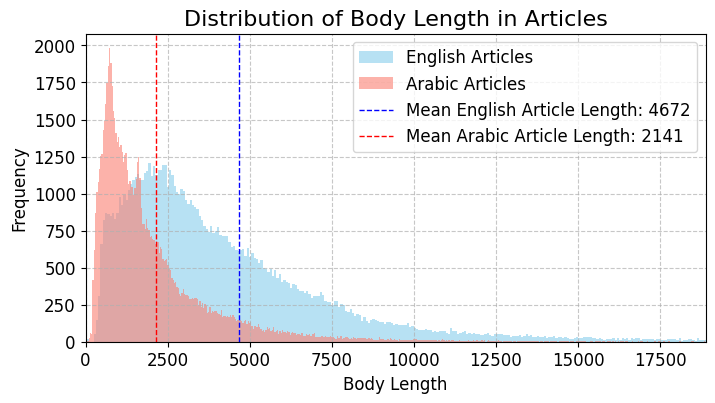

In [7]:
# Example data generation for demonstration
# Assuming `eng` and `ara` are DataFrames with a column `body_len`
eng_q98 = eng["body_len"].quantile(0.98)
ara_q98 = ara["body_len"].quantile(0.98)

plt.figure(figsize=(8, 4))
plt.hist(eng["body_len"], bins=1000, alpha=0.6, label="English Articles", color='skyblue')
plt.hist(ara["body_len"], bins=1000, alpha=0.6, label="Arabic Articles", color='salmon')

plt.axvline(eng["body_len"].mean(), color='blue', linestyle='dashed', linewidth=1, label=f"Mean English Article Length: {eng['body_len'].mean():.0f}")
plt.axvline(ara["body_len"].mean(), color='red', linestyle='dashed', linewidth=1, label=f"Mean Arabic Article Length: {ara['body_len'].mean():.0f}")

plt.xlim(0, max(ara_q98, eng_q98))
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Body Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Body Length in Articles', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

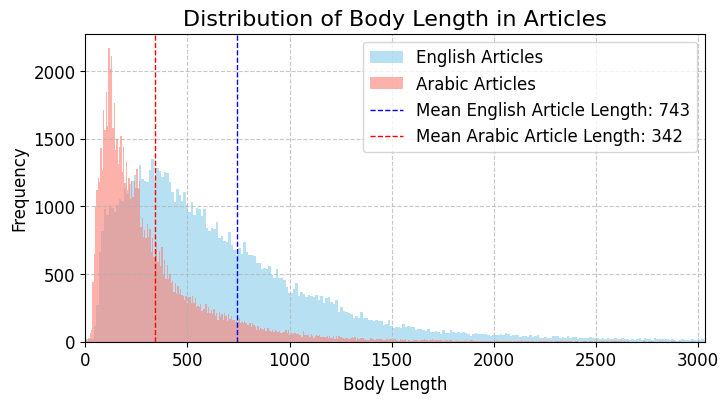

In [8]:
# Example data generation for demonstration
# Assuming `eng` and `ara` are DataFrames with a column `body_len`
eng_q98 = eng["body_len_str"].quantile(0.98)
ara_q98 = ara["body_len_str"].quantile(0.98)

plt.figure(figsize=(8, 4))
plt.hist(eng["body_len_str"], bins=1000, alpha=0.6, label="English Articles", color='skyblue')
plt.hist(ara["body_len_str"], bins=1000, alpha=0.6, label="Arabic Articles", color='salmon')

plt.axvline(eng["body_len_str"].mean(), color='blue', linestyle='dashed', linewidth=1, label=f"Mean English Article Length: {eng['body_len_str'].mean():.0f}")
plt.axvline(ara["body_len_str"].mean(), color='red', linestyle='dashed', linewidth=1, label=f"Mean Arabic Article Length: {ara['body_len_str'].mean():.0f}")

plt.xlim(0, max(ara_q98, eng_q98))
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Body Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Body Length in Articles', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2 Publishing date vs scraping date

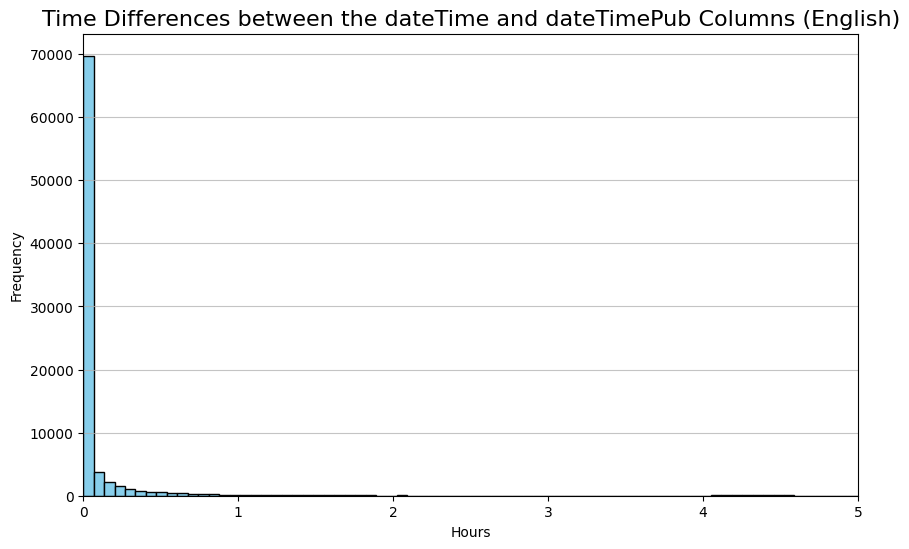

In [9]:
eng["diff"] = pd.to_datetime(eng["dateTime"]) - pd.to_datetime(eng["dateTimePub"])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(eng["diff"].dt.total_seconds() / 3600, bins=1000, edgecolor='black', color='skyblue')
plt.title('Time Differences between the dateTime and dateTimePub Columns (English)', fontsize=16)
plt.xlabel('Hours')
plt.xlim(0, 5)
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

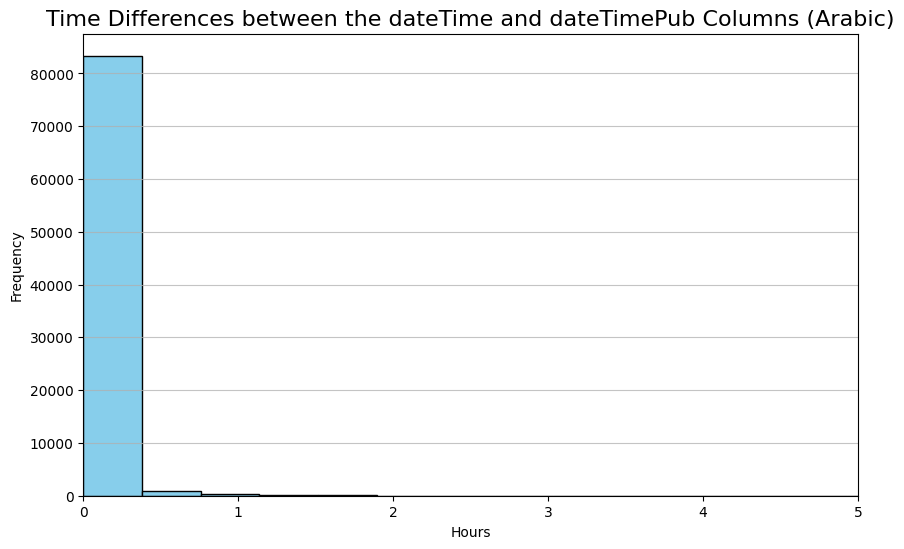

In [10]:
ara["diff"] = pd.to_datetime(ara["dateTime"]) - pd.to_datetime(ara["dateTimePub"])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(ara["diff"].dt.total_seconds() / 3600, bins=1000, edgecolor='black', color='skyblue')
plt.title('Time Differences between the dateTime and dateTimePub Columns (Arabic)', fontsize=16)
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.xlim(0, 5)
plt.grid(axis='y', alpha=0.75)

# 3 Summary of Articles mentioning countries, provinces and districts with and without keywords

Note that in this summary, articles that mention multiple districts or that mention multiple keywords or keywords multiple times appear in each column only once. 

In [11]:
def create_count_summary_df(language_df: pd.DataFrame, location_names_dict : dict, keyword_columns: list, country_codes: dict):
    """
    Creates a summary DataFrame that counts the number of articles and keywords for each country and its provinces/districts.

    Args:
        language_df (pd.DataFrame): The DataFrame containing the language-specific articles.
        keyword_columns (list): A list of column names representing the keyword columns in the DataFrame.
        country_codes (dict): A dictionary mapping country codes to their corresponding names.

    Returns:
        pd.DataFrame: A DataFrame summarizing the article and keyword counts for each country and its provinces/districts.
    """
    articles = language_df.shape[0]
    articles_keywords = language_df.loc[language_df[keyword_columns].sum(axis=1) > 0,].shape[0]

    country_code_list = []
    articles_country_list = []
    articles_country_provinces_list = []
    articles_provinces_list = []
    articles_country_districts_list = []
    articles_districts_list = []
    articles_country_keywords_list = []
    articles_country_provinces_keywords_list = []
    articles_provinces_keywords_list = []
    articles_country_districts_keywords_list = []
    articles_districts_keywords_list = []
    
    #print(f'Out of {articles} {languages[language_df["lang"].unique()[0]]} articles from {language_df["date"].min().date()} to {language_df["date"].max().date()}, {articles_keywords} ({np.round(articles_keywords/articles*100,2)} %) mention keywords:')
    for country_code in country_codes.keys():
        
        provinces = [key for key in location_names_dict.keys() if (len(key.split("_")) == 2) and (key.split("_")[0] == country_code)]
        districts = [key for key in location_names_dict.keys() if (len(key.split("_")) == 3) and (key.split("_")[0] == country_code)]
        
        articles_country = language_df.loc[language_df[country_code] > 0, ].shape[0]
        articles_country_provinces = language_df.loc[(language_df[country_code] > 0) & (language_df[provinces].sum(axis=1) > 0),].shape[0]
        articles_provinces = language_df.loc[(language_df[provinces].sum(axis=1) > 0),].shape[0]
        articles_country_districts = language_df.loc[(language_df[country_code] > 0) & (language_df[districts].sum(axis=1) > 0),].shape[0]
        articles_districts = language_df.loc[(language_df[districts].sum(axis=1) > 0),].shape[0]
        
        articles_country_keywords = language_df.loc[(language_df[country_code] > 0) & (language_df[keyword_columns].sum(axis=1) > 0), ].shape[0]
        articles_country_provinces_keywords = language_df.loc[(language_df[country_code] > 0) & (language_df[provinces].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        articles_provinces_keywords = language_df.loc[(language_df[provinces].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        
        articles_country_districts_keywords = language_df.loc[(language_df[country_code] > 0) & (language_df[districts].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        articles_districts_keywords = language_df.loc[(language_df[districts].sum(axis=1) > 0) & (language_df[keyword_columns].sum(axis=1) > 0),].shape[0]
        
        country_code_list.append(country_code)
        articles_country_list.append(articles_country)
        articles_country_provinces_list.append(articles_country_provinces)
        articles_provinces_list.append(articles_provinces)
        articles_country_districts_list.append(articles_country_districts)
        articles_districts_list.append(articles_districts)
        articles_country_keywords_list.append(articles_country_keywords)
        articles_country_provinces_keywords_list.append(articles_country_provinces_keywords)
        articles_provinces_keywords_list.append(articles_provinces_keywords)
        articles_country_districts_keywords_list.append(articles_country_districts_keywords)
        articles_districts_keywords_list.append(articles_districts_keywords)
                
        #print(f"\t- {country_codes[country_code]}: {articles_country_keywords} of {articles_country} ({np.round(articles_country_keywords / articles_country * 100,2)} %), provinces of {country_codes[country_code]}: {articles_provinces_keywords} of {articles_provinces} ({np.round(articles_provinces_keywords / articles_provinces * 100,2)} %), both: {articles_country_provinces_keywords} of {articles_country_provinces} ({np.round(articles_country_provinces_keywords / articles_country_provinces * 100,2)} %).")
        
    mention_count_df = pd.DataFrame({"country_code": country_code_list, "articles_country": articles_country_list, "articles_country_provinces": articles_country_provinces_list, "articles_provinces": articles_provinces_list, "articles_country_districts": articles_country_districts_list, "articles_districts": articles_districts_list, "articles_country_keywords": articles_country_keywords_list, "articles_country_provinces_keywords": articles_country_provinces_keywords_list, "articles_provinces_keywords": articles_provinces_keywords_list, "articles_country_districts_keywords": articles_country_districts_keywords_list, "articles_districts_keywords": articles_districts_keywords_list})
    return mention_count_df

In [12]:
# Creating a dictionary with the country ids and corresponding country names
country_ids = [key for key in location_names_dict_eng if len(key.split("_")) == 1]

country_codes = {}
for id in country_ids:
    country_codes[id] = location_names_dict_eng[id][0]
    
country_codes["ps"] = "palestine"

In [13]:
# English
mention_count_df_eng = create_count_summary_df(eng, location_names_dict_eng, list(keywords_dict_eng.keys()), country_codes)

In [14]:
# Arabic
mention_count_df_ara = create_count_summary_df(ara, location_names_dict_ara, list(keywords_dict_ara.keys()), country_codes)

In [15]:
def plot_mention_count_summary(mention_count_df:pd.DataFrame, language: Literal["eng", "ara"], from_date: str, to_date: str, plot_path: str, save_plot: bool = False):

    languages = {"ara": "Arabic", "eng": "English"}
    # Calculate the first bar heights
    articles_country_no_keywords = mention_count_df["articles_country"] - mention_count_df["articles_country_keywords"]
    articles_provinces_no_keywords = mention_count_df["articles_provinces"] - mention_count_df["articles_provinces_keywords"]
    articles_country_provinces_no_keywords = mention_count_df["articles_country_provinces"] - mention_count_df["articles_country_provinces_keywords"]
    articles_districts_no_keywords = mention_count_df["articles_districts"] - mention_count_df["articles_districts_keywords"]
    articles_country_districts_no_keywords = mention_count_df["articles_country_districts"] - mention_count_df["articles_country_districts_keywords"]

    labels = ["Country", "Province", "Country & Province", "Districts", "Country & Districts"]
    labels = np.repeat(labels,5)

    # Define the positions for each group of bars
    n_groups = len(mention_count_df)
    bar_height = 0.15
    index = np.arange(n_groups)

    # Plot the bars
    plt.figure(figsize=(12, 8))

    # Type 1 - Articles per Country
    plt.barh(
        index, 
        articles_country_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        label='Not Including Keywords'
    )
    plt.barh(
        index, 
        mention_count_df["articles_country_keywords"], 
        bar_height, 
        left=articles_country_no_keywords, 
        color='green', 
        edgecolor="black",
        label='Including Keywords'
    )

    # Type 2 - Articles per Province
    plt.barh(
        index + bar_height, 
        articles_provinces_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + bar_height, 
        mention_count_df["articles_provinces_keywords"], 
        bar_height, 
        left=articles_provinces_no_keywords, 
        color='green', 
        edgecolor="black",
        #label='Including Keywords'
    )

    # Type 3 - Articles per Country and Province
    plt.barh(
        index + 2 * bar_height, 
        articles_country_provinces_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + 2 * bar_height, 
        mention_count_df["articles_country_provinces_keywords"], 
        bar_height, 
        left=articles_country_provinces_no_keywords, 
        color='green', 
        edgecolor="black",
        #label='Including Keywords'
    )

    # Type 4 - Articles per District
    plt.barh(
        index + 3 * bar_height, 
        articles_districts_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + 3 * bar_height, 
        mention_count_df["articles_districts_keywords"], 
        bar_height, 
        left=articles_districts_no_keywords, 
        color='green', 
        edgecolor="black",
        #label='Including Keywords'
    )

    # Type 5 - Articles per Country and District
    plt.barh(
        index + 4 * bar_height, 
        articles_country_districts_no_keywords, 
        bar_height, 
        color='salmon', 
        edgecolor="black",
        #label='Not Including Keywords'
    )
    plt.barh(
        index + 4 * bar_height, 
        mention_count_df["articles_country_districts_keywords"], 
        bar_height, 
        left=articles_country_districts_no_keywords, 
        color='green', 
        edgecolor="black"
        #label='Including Keywords'
    )

    # Add labels and title
    plt.xlabel('Number of Articles')
    plt.title(f'Number of {languages[language]} Articles Mentioning Keywords by Country and Administrative Level from {from_date} to {to_date}', loc='center', pad=20, x=0.4)
    label_locations = list(index) + list(index + bar_height) + list(index + 2 * bar_height) + list(index + 3 * bar_height) + list(index + 4 * bar_height)
    plt.yticks(label_locations, labels)

    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[4] + 2 * bar_height, "Syria", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[3] + 2 * bar_height, "Palestine", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[2] + 2 * bar_height, "Lebanon", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[1] + 2 * bar_height, "Jordan", fontsize=18, color='black')
    plt.text(-np.max(mention_count_df.max().values[1:])/3.2, index[0] + 2 * bar_height, "Iraq", fontsize=18, color='black')
    plt.legend()

    plt.tight_layout()
    if save_plot:
        plt.savefig(plot_path + "keyword-admin-level/" + f"summary_{from_date}_to_{to_date}_{language}.png")
        
    # Display the plot
    plt.show()

In [16]:
from_date = str(pd.to_datetime(eng["date"]).min().date())
to_date = str(pd.to_datetime(eng["date"]).max().date())

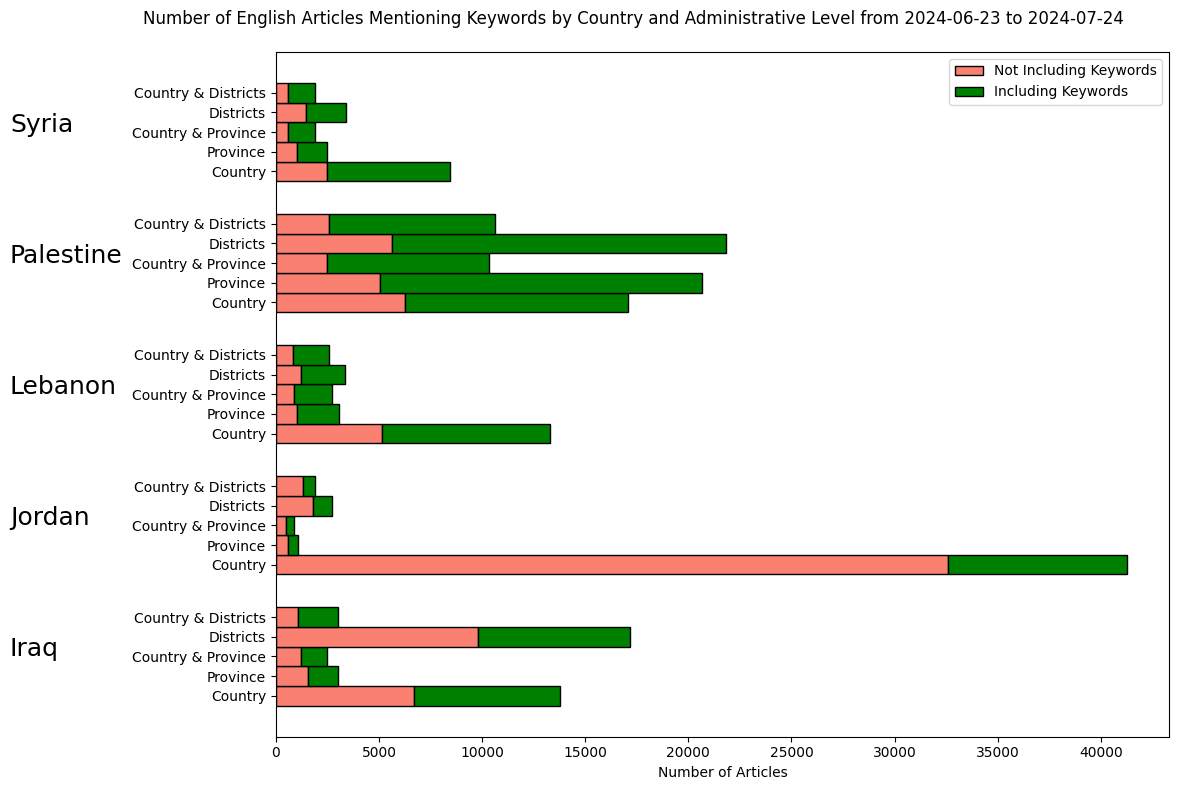

In [17]:
# English
plot_mention_count_summary(mention_count_df_eng, "eng", from_date, to_date, plot_path, save_plot = False)

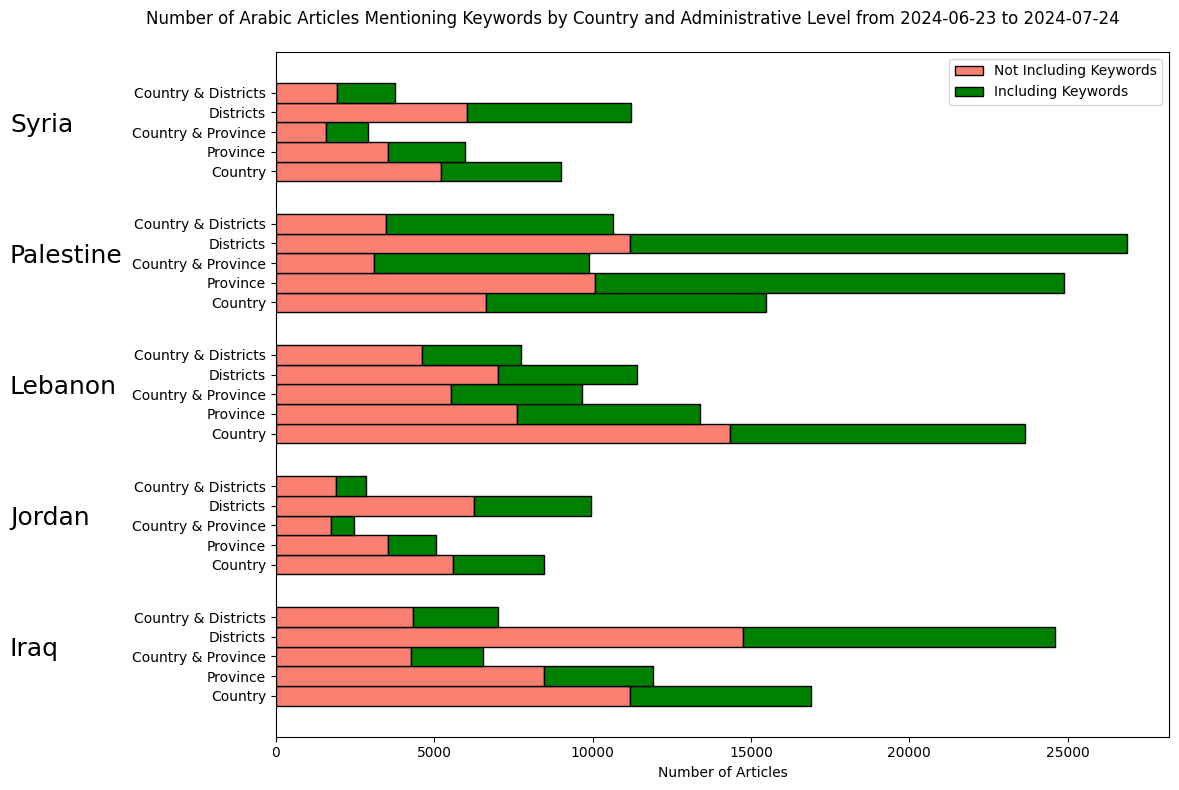

In [18]:
# Arabic
plot_mention_count_summary(mention_count_df_ara, "ara", from_date, to_date, plot_path, save_plot = False)

# 4 Summary of articles for locations as admin level 0, level 1 and level 2 per day

## 4.1 Aggregating the summary table to weeks, months or years

In [21]:
def unique_strings(series):
    return ', '.join(series.dropna().astype(str).unique())

def aggregate_summary_by_dates(summary_df: pd.DataFrame, level_of_aggregation:Literal["W", "M", "Y"]) -> pd.DataFrame:
    summary_df_agg = summary_df.groupby(["location"]).resample(level_of_aggregation).agg({col: 'sum' if summary_df[col].dtype != 'object' else unique_strings for col in summary_df.columns})
    summary_df_agg = summary_df_agg.drop(columns=["location"]).reset_index()
    summary_df_agg.sort_values(by=["country", "location"], ascending=False, inplace=True)
    return summary_df_agg

In [22]:
# English
summary_df_eng_W = aggregate_summary_by_dates(summary_df_eng, "W")  # Weekly aggregation
summary_df_eng_Y = aggregate_summary_by_dates(summary_df_eng, "YE") # Yearly aggregation

In [23]:
# Arabic
summary_df_ara_W = aggregate_summary_by_dates(summary_df_ara, "W")  # Weekly aggregation
summary_df_ara_Y = aggregate_summary_by_dates(summary_df_ara, "YE") # Yearly aggregation

## 4.2 Plot the aggregated article counts per location

In [24]:
def plot_keyword_province(summary_df: pd.DataFrame, language_df: pd.DataFrame, country: str, plot_path: str, admin_level: str = "district", save_plot: bool = False):
    language_df["date"] = pd.to_datetime(language_df["date"])
    from_date = language_df["date"].min().date()
    to_date = language_df["date"].max().date()
    languages = {"ara": "Arabic", "eng": "English"}
    language = languages[language_df["lang"].unique()[0]]

    
    if admin_level == "district":
        
        # Filter for the country and the admin level Districts
        adminlevel_df = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"] == 2),].groupby("location").sum()
        adminlevel_df.reset_index(inplace=True)
        admin_names = adminlevel_df["location"].apply(lambda x: id_unique_location_names[x])
        
        article_count = adminlevel_df["count_articles"].values
        article_with_keywords_count = adminlevel_df["kw"].values
        total_locations = adminlevel_df.shape[0]
        locations_with_data_no_keywords = adminlevel_df[(adminlevel_df["count_articles"] > 0) & (adminlevel_df["count_articles"] - adminlevel_df["kw"] > 0)].shape[0]
        locations_with_keywords = adminlevel_df[(adminlevel_df["kw"] > 0)].shape[0]
    
        
    elif admin_level == "province":
        
        # Filter for the country and the admin level Provinces
        adminlevel_df = summary_df.loc[(summary_df["country"] == country) & (summary_df["admin_level"] == 1),].groupby("location").sum()
        adminlevel_df.reset_index(inplace=True)
        admin_names = adminlevel_df["location"].apply(lambda x: id_unique_location_names[x])
        
        article_count = adminlevel_df["count_articles"].values
        article_with_keywords_count = adminlevel_df["kw"].values
        total_locations = adminlevel_df.shape[0]
        locations_with_data_no_keywords = adminlevel_df[(adminlevel_df["count_articles"] > 0) & (adminlevel_df["count_articles"] - adminlevel_df["kw"] > 0)].shape[0]
        locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]
    
    else:
        print("Admin level not specified correctly, needs to be either 'district' or 'province'")
        
    article_with_no_keywords_count = article_count - article_with_keywords_count

    plt.figure(figsize=(6, max(6,int(len(admin_names)/60))))
    # Create the plot
    plt.barh(admin_names, article_with_no_keywords_count, color='salmon', label=f'Articles without Keywords (in {locations_with_data_no_keywords} {admin_level.capitalize()}s)')
    plt.barh(admin_names, article_with_keywords_count, left=article_with_no_keywords_count, color='green', label=f'Articles with Keywords (in {locations_with_keywords} {admin_level.capitalize()}s)')
    plt.xlabel('Article Count')
    plt.ylabel(f'{admin_level.capitalize()}')
    plt.title(f'{id_unique_location_names[country]} - {language} Articles - {total_locations} {admin_level.capitalize()}s ({from_date} to {to_date})')
    plt.legend()

    plt.tight_layout()
    
    # Display the plot
    if save_plot:
        plt.savefig(plot_path + "keyword-admin-level/" + f"{country.lower()}_{admin_level}s_{from_date}_to_{to_date}_{language_df['lang'].unique()[0]}.png")
    plt.show()
    


/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


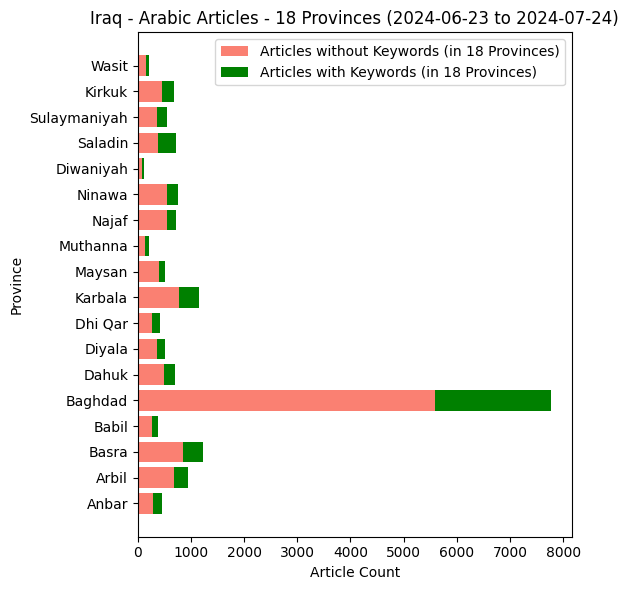

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


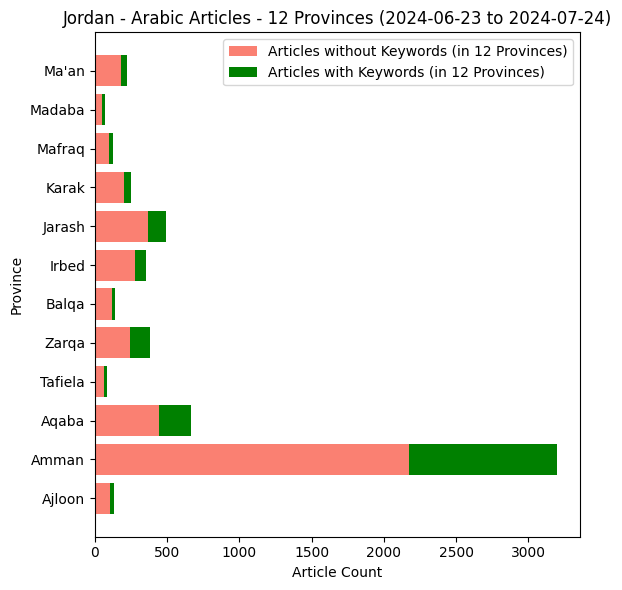

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


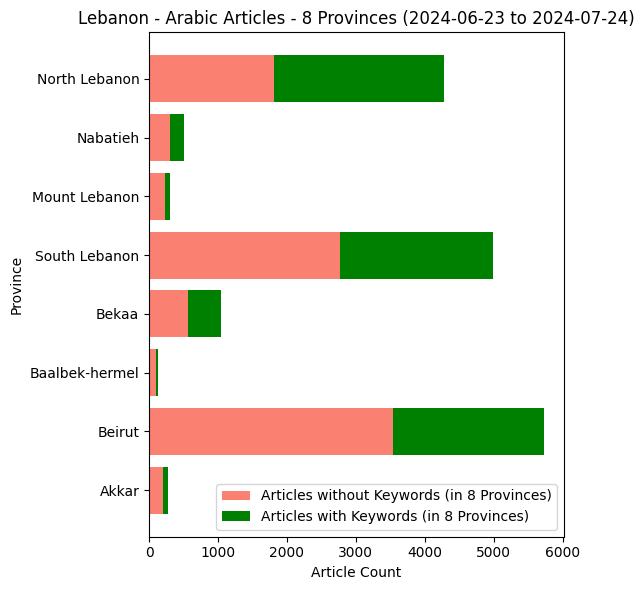

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


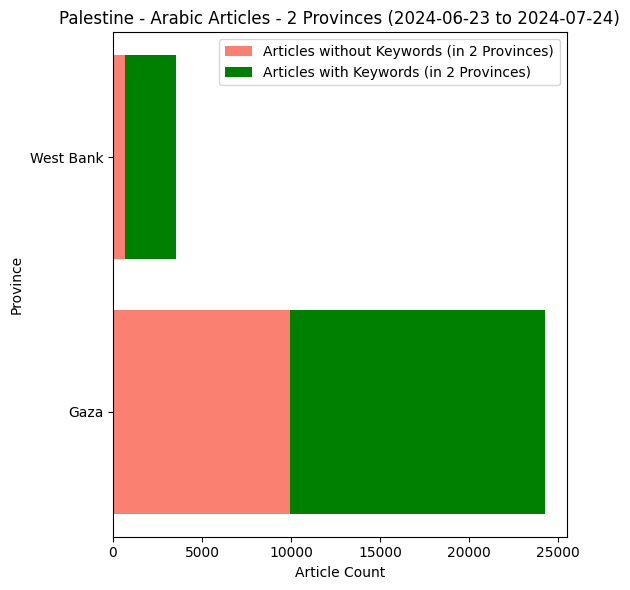

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


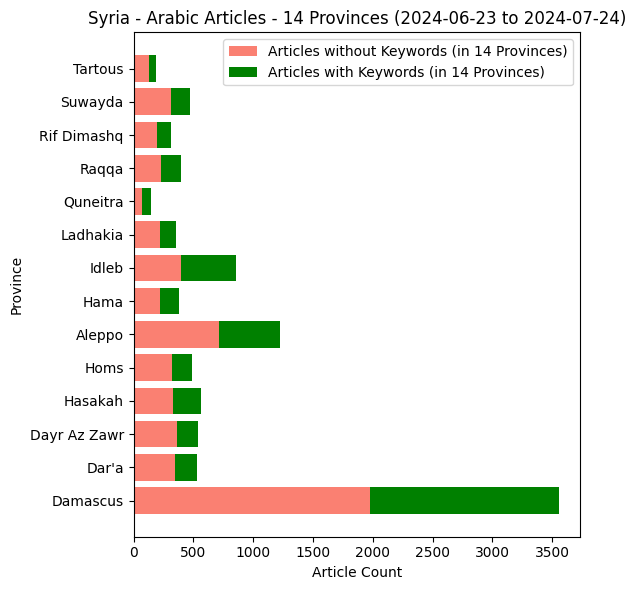

In [25]:
# Arabic
countries = ["iq", "jo", "lb", "ps", "sy"]
#admin_level = "district"
admin_level = "province"
summary_df = summary_df_ara

for country in countries:
    plot_keyword_province(summary_df = summary_df, language_df = ara, country = country, plot_path = plot_path, admin_level = admin_level, save_plot = False)

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


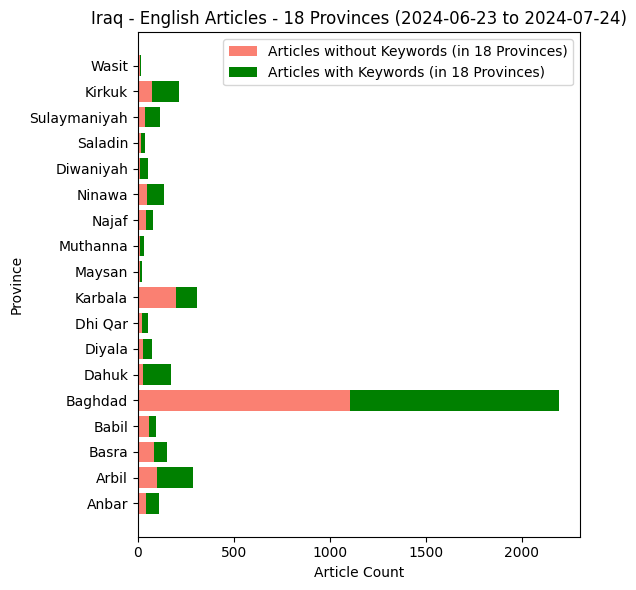

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


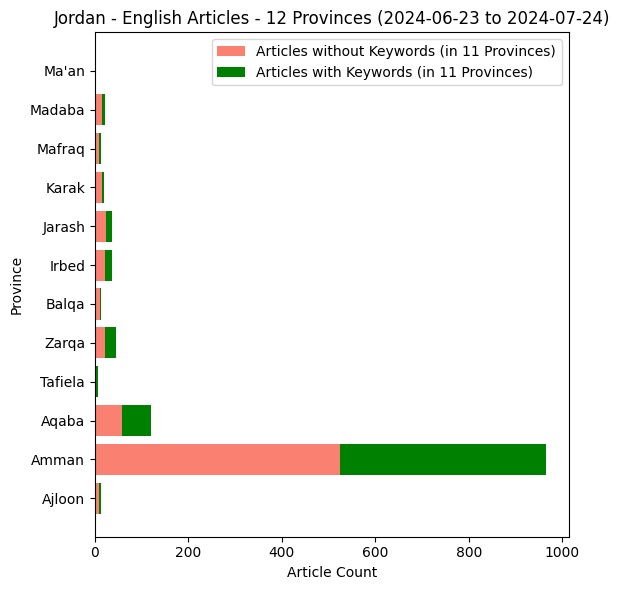

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


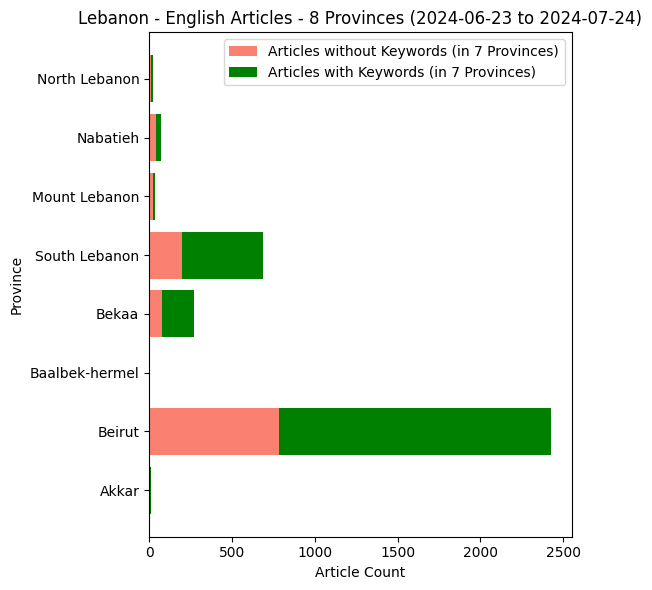

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


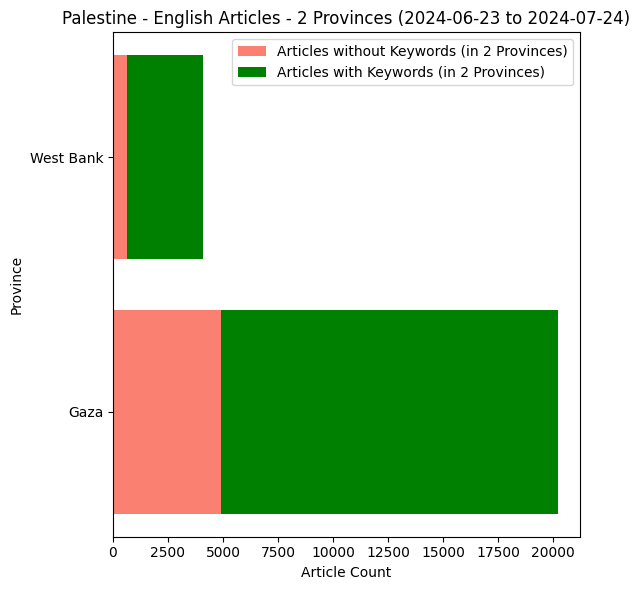

/tmp/ipykernel_101938/3172662743.py:34: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  locations_with_keywords = adminlevel_df[((adminlevel_df["count_articles"] > 0) & ["kw"] > 0)].shape[0]


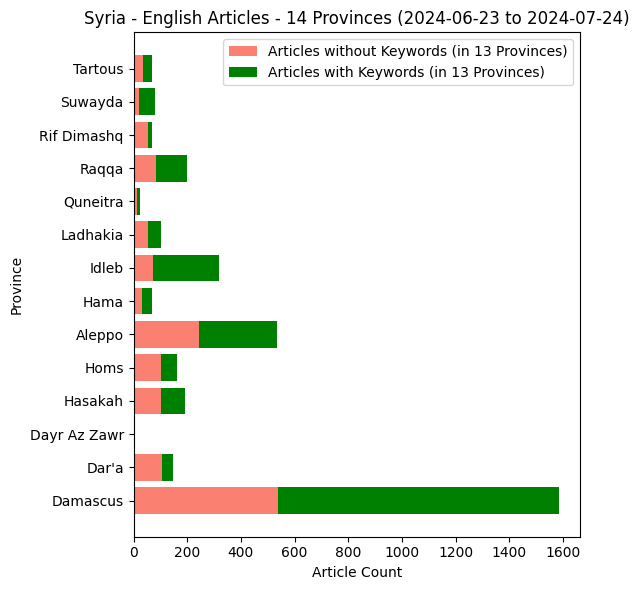

In [26]:
# English
countries = ["iq", "jo", "lb", "ps", "sy"]
#admin_level = "district"
admin_level = "province"
for country in countries:
    plot_keyword_province(summary_df = summary_df_eng, language_df = eng, country = country, plot_path = plot_path, admin_level = admin_level, save_plot = False)

## 4.4 Plot the article keyword group counts per country

In [27]:
def create_keyword_groups_count(summary_df: pd.DataFrame, language: Literal["eng", "ara"], location: str, save=False):
    languages = {"ara": "Arabic", "eng": "English"}
    # Filter the dataframe for the specified location
    province_df = summary_df.loc[summary_df["location"] == location]

    # Convert dates to calendar weeks
    province_df["date"] = province_df["date"].dt.isocalendar().week

    # Set the date as the index
    province_df.set_index('date', inplace=True)

    # Select the columns to stack
    columns_to_stack = ['cv', 'pi', 'ha', 'eci', 'prs', 'ws', 'fc', 'lri', 'pad', 'fd', 'ei', 'o', 'nc']

    # Extract the data for the plot and normalize it
    data_to_plot = province_df[columns_to_stack]
    normalized_data = data_to_plot.div(data_to_plot.sum(axis=1), axis=0)


    
    # Create a figure with two subplots, one below the other without sharing the x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

    # Plot the absolute counts on the first subplot
    data_to_plot.plot(kind='barh', stacked=True, ax=ax1, colormap='tab20', width=0.85)
    ax1.set_title(f'Absolute Counts of Keyword Containing Articles per Group in {languages[language]} Articles Mentioning {id_unique_location_names[location]}')
    ax1.set_ylabel('Calendar Week (2024)')
    ax1.invert_yaxis()  # Invert y-axis to have the latest date at the top
    ax1.legend().remove()  # Remove the legend from the first plot

    # Plot the normalized data on the second subplot
    normalized_data.plot(kind='barh', stacked=True, ax=ax2, colormap='tab20', width=0.85)
    ax2.set_title(f'Share of Keyword Containing Articles per Group in {languages[language]} Articles Mentioning {id_unique_location_names[location]}')
    ax2.set_xlabel('Proportion')
    ax2.set_ylabel('Calendar Week (2024)')
    ax2.invert_yaxis()  # Invert y-axis to have the latest date at the top

    # Custom legend labels
    custom_labels = [keyword_category_name[col] for col in columns_to_stack]

    # Update legend with custom labels and position it below the second plot
    ax2.legend(custom_labels, title='Keyword Groups', bbox_to_anchor=(0.5, -0.35), loc='upper center', ncol=4)

    # Adjust layout to prevent clipping of the legend and titles
    plt.tight_layout()
    if save == True:
        plt.savefig(plot_path + "keyword-province/" + f"weekly_{location}_{language}.png", bbox_inches='tight')
    plt.show()

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


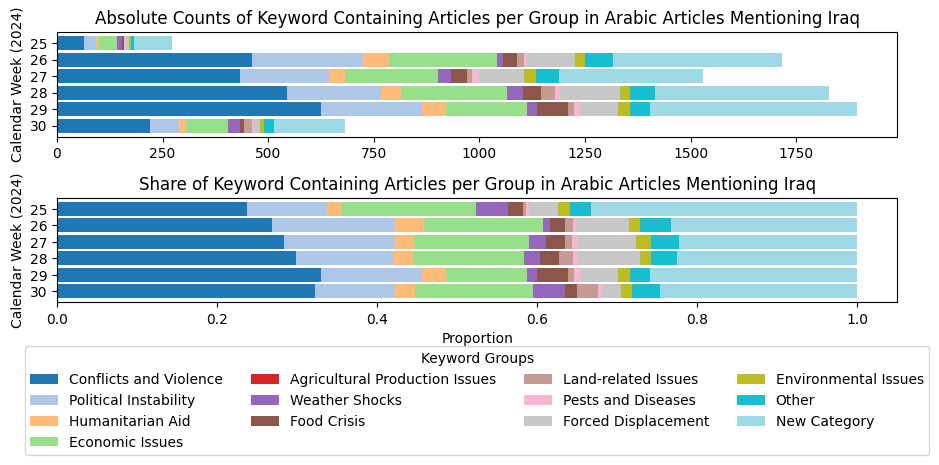

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


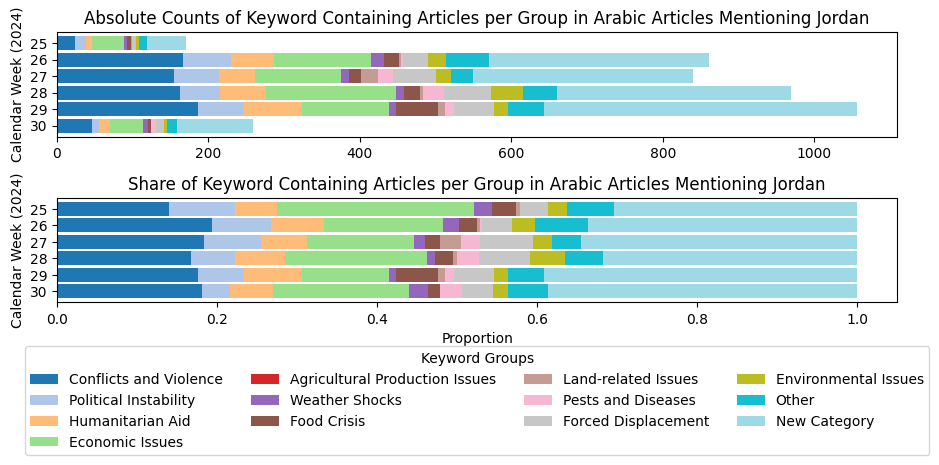

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


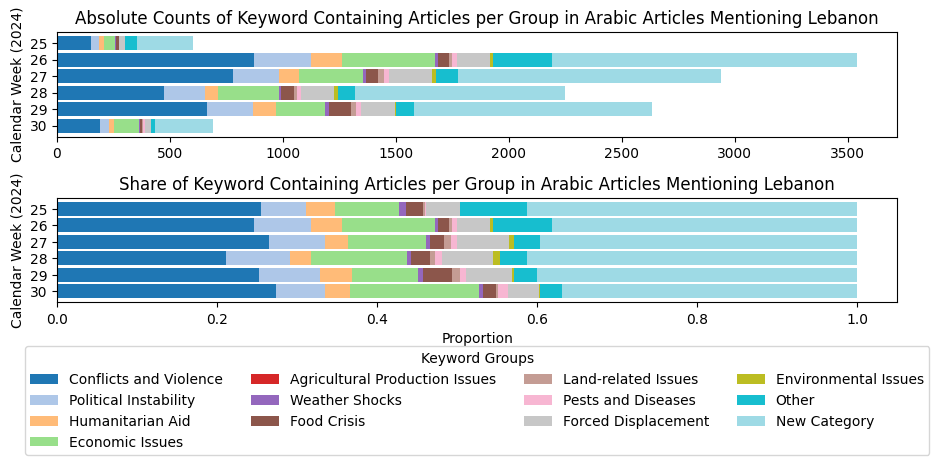

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


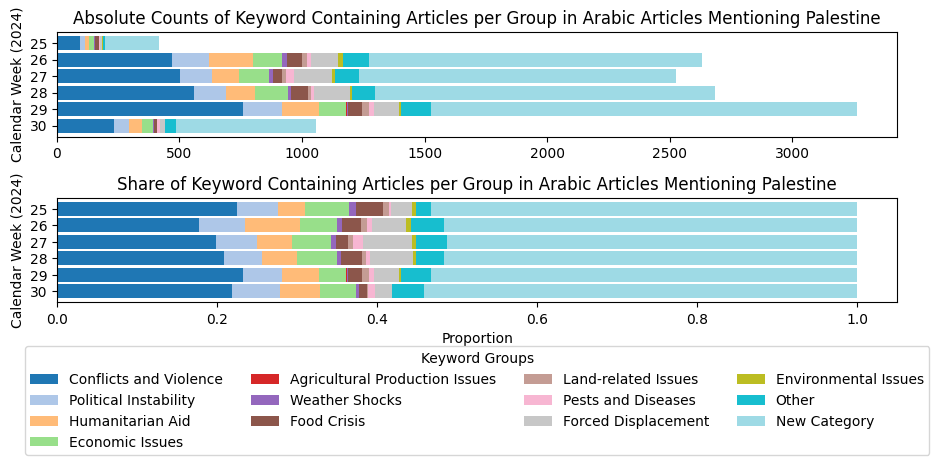

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


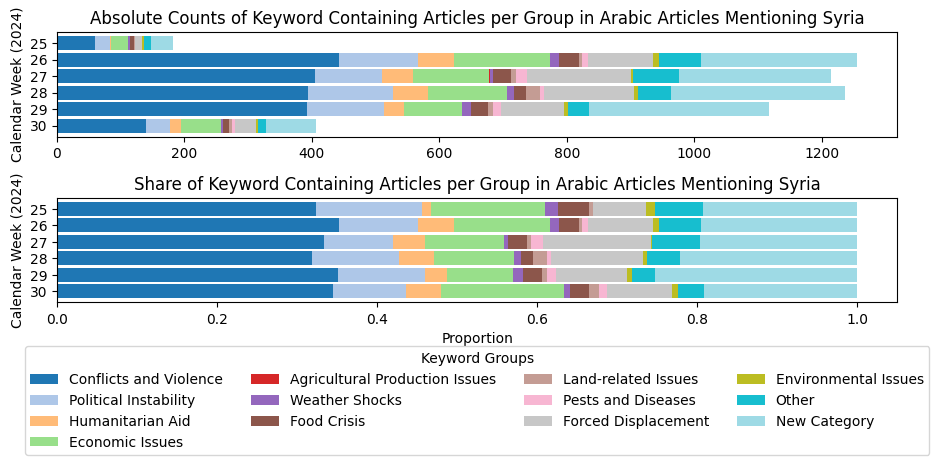

In [28]:
countries = ["iq", "jo", "lb", "ps", "sy"]

for country in countries:
    summary_df = summary_df_ara_W
    create_keyword_groups_count(summary_df = summary_df, language = "ara", location = country)

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


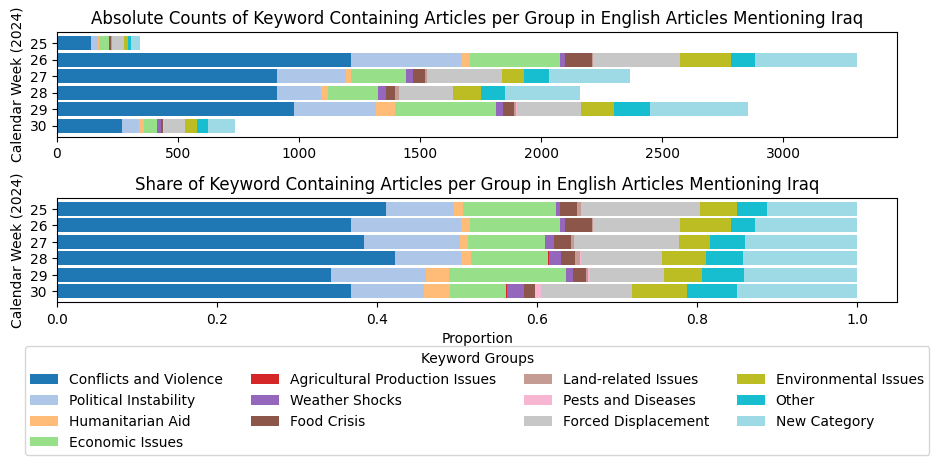

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


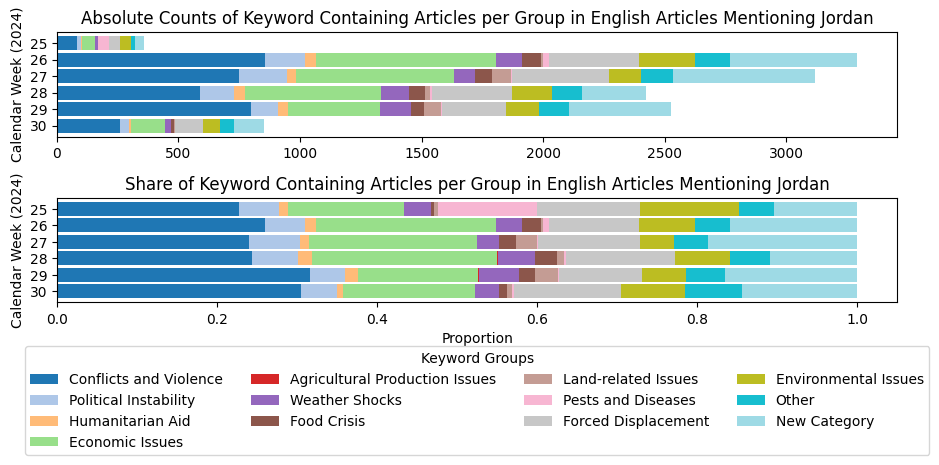

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


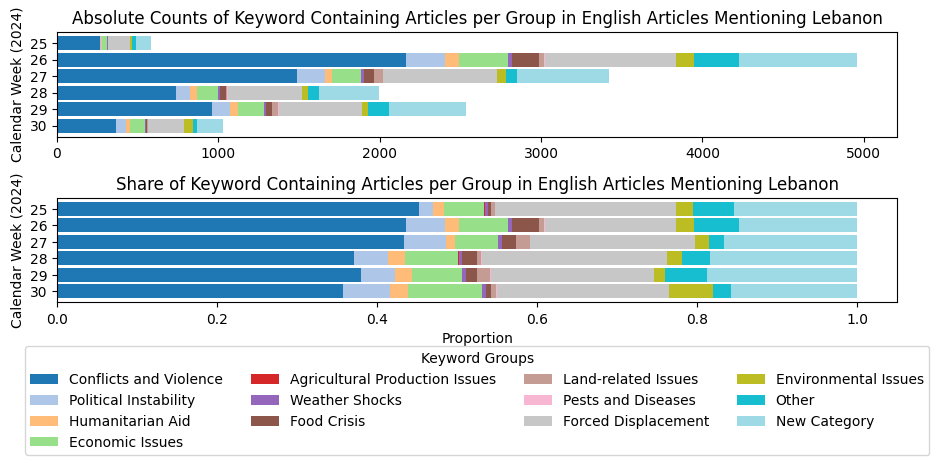

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


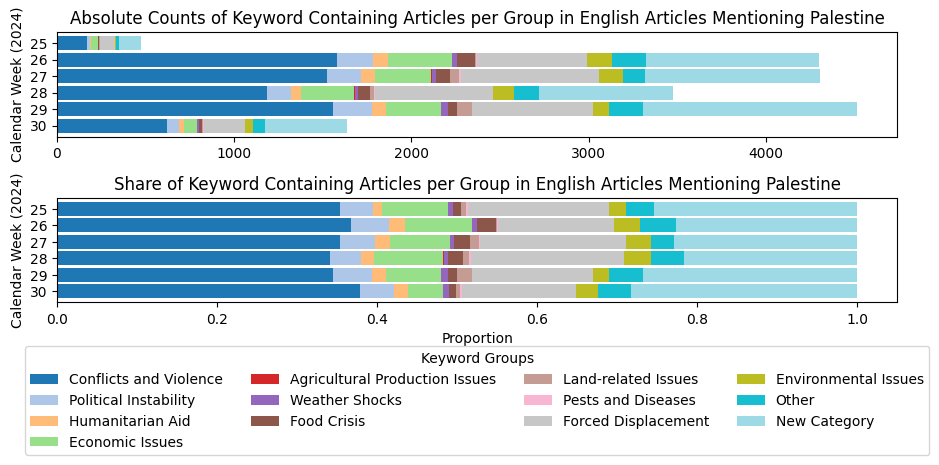

/tmp/ipykernel_101938/90703822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  province_df["date"] = province_df["date"].dt.isocalendar().week


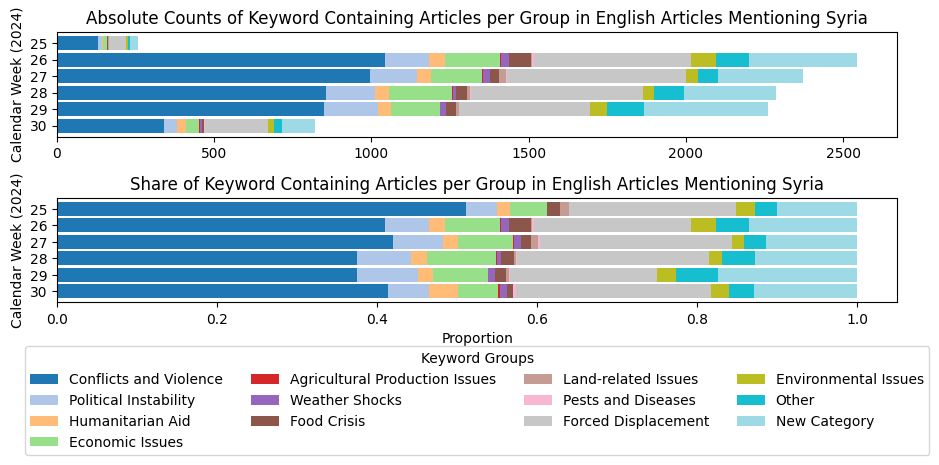

In [29]:
countries = ["iq", "jo", "lb", "ps", "sy"]

for country in countries:
    summary_df = summary_df_eng_W
    create_keyword_groups_count(summary_df = summary_df, language = "eng", location = country)

# 5 Time series for different locations and keywords

In [30]:
# Creating Calendar week column
eng["cw"] = eng["date"].dt.isocalendar().week

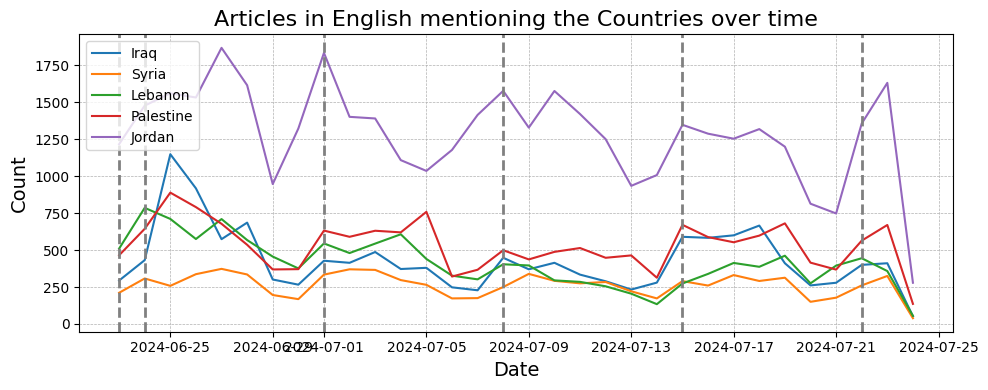

In [31]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eng.loc[(eng["iq"] > 0)].groupby("date").size(), label="Iraq")
ax.plot(eng.loc[(eng["sy"] > 0)].groupby("date").size(), label="Syria")
ax.plot(eng.loc[(eng["lb"] > 0)].groupby("date").size(), label="Lebanon")
ax.plot(eng.loc[(eng["ps"] > 0)].groupby("date").size(), label="Palestine")
ax.plot(eng.loc[(eng["jo"] > 0)].groupby("date").size(), label="Jordan")

# Enhance plot appearance
ax.set_title('Articles in English mentioning the Countries over time', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks()

# Add vertical lines at the end of each calendar week
weeks = eng.groupby("cw")["date"].min().values
for week_end in weeks:
    ax.axvline(x=week_end, color='gray', linestyle='--', linewidth=2)

# Show plot
plt.tight_layout()
plt.show()

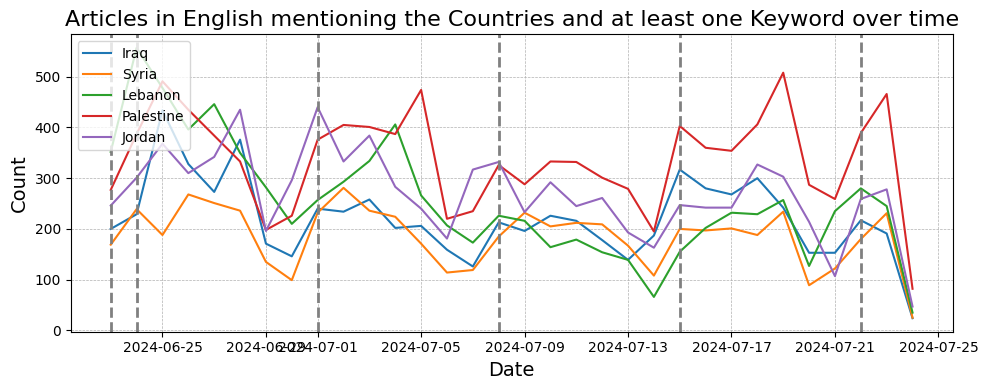

In [32]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eng.loc[(eng["iq"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Iraq")
ax.plot(eng.loc[(eng["sy"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Syria")
ax.plot(eng.loc[(eng["lb"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Lebanon")
ax.plot(eng.loc[(eng["ps"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Palestine")
ax.plot(eng.loc[(eng["jo"] > 0) & (eng["kw_all"] > 0)].groupby("date").size(), label="Jordan")

# Enhance plot appearance
ax.set_title('Articles in English mentioning the Countries and at least one Keyword over time', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks()

# Add vertical lines at the end of each calendar week
weeks = eng.groupby("cw")["date"].min().values
for week_end in weeks:
    ax.axvline(x=week_end, color='gray', linestyle='--', linewidth=2)

# Show plot
plt.tight_layout()
plt.show()

In [33]:
iraq_df = summary_df_eng.loc[summary_df_eng["location"] == "iq"]
iraq_df.reset_index(inplace=True)

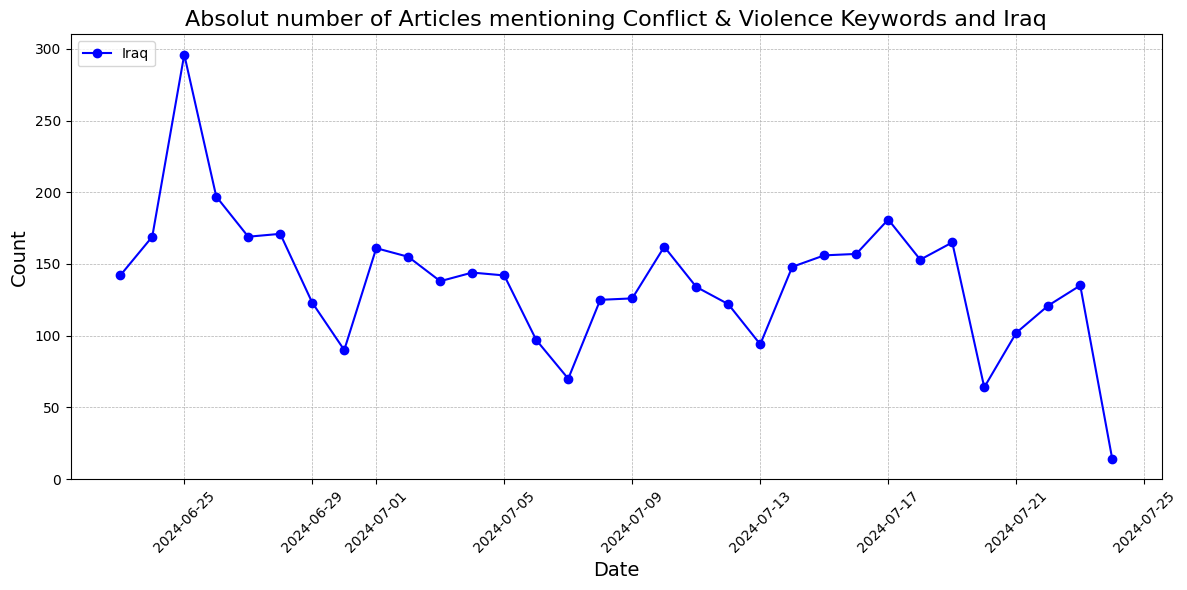

In [34]:
# Plot the data
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(iraq_df["date"], iraq_df["cv"], label="Iraq", color='blue', marker='o', linestyle='-')

# Enhance plot appearance
ax.set_title('Absolut number of Articles mentioning Conflict & Violence Keywords and Iraq', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()

In [37]:
# Mapping country IDs to country names
country_codes = {}
for country_key in [key for key in id_unique_location_names.keys() if len(key.split("_")) == 1]:
    country_codes[country_key] = id_unique_location_names[country_key]
    
# Mapping language IDs to language names    
languages = {"ara": "Arabic", "eng": "English"}

# Selecting Iraq
location = list(country_codes.keys())[0]
#summary_df_loc = summary_df_eng.loc[summary_df_eng["location"] == location]
summary_df_loc = summary_df_eng.loc[summary_df_eng["location"].apply(lambda x: x.split("_")[0] == "iq")]

In [42]:
summary_df_loc = summary_df_loc.groupby("date").sum()

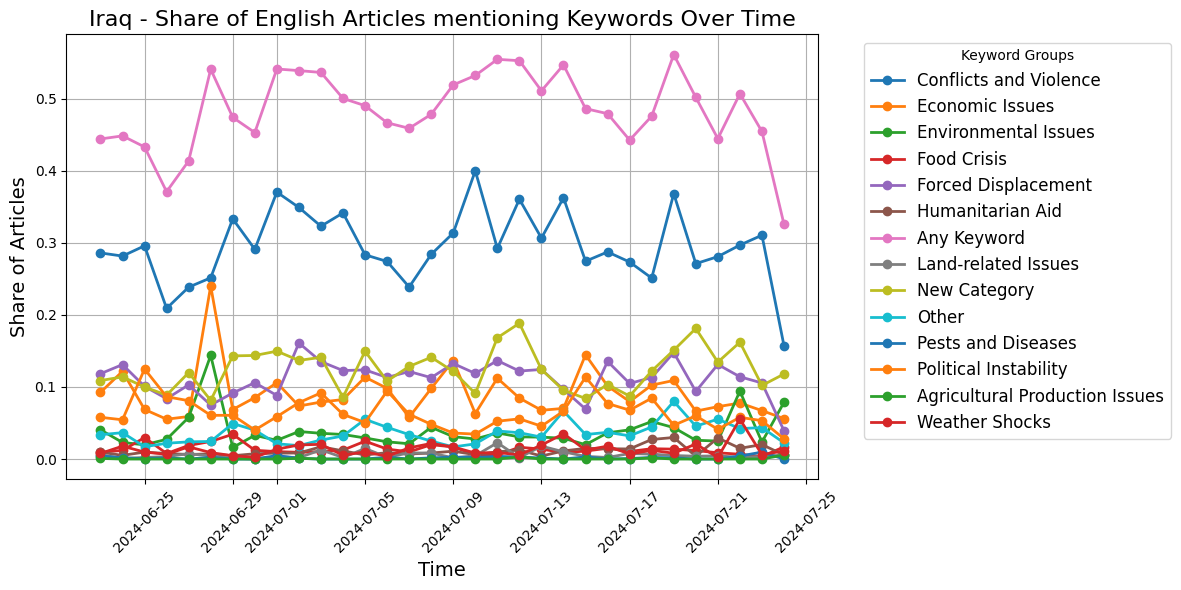

In [43]:
# Plotting
plt.figure(figsize=(12, 6))

# Calculate share of articles mentioning keywords
normalized_data = summary_df_loc[keyword_category_name.keys()].apply(lambda x: x / summary_df_loc["count_articles"])
for keyword in keyword_category_name.keys():
    plt.plot(normalized_data[keyword], marker='o', linestyle='-', linewidth=2, label=keyword)

# Adding title and labels
plt.title(f'{id_unique_location_names[location]} - Share of English Articles mentioning Keywords Over Time', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Share of Articles', fontsize=14)

# Adding a legend
plt.legend(list(keyword_category_name.values()), title='Keyword Groups', loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=12)

# Improve date formatting if the x-axis represents dates
plt.xticks(rotation=45)

# Adding grid lines for better readability
plt.grid(True)

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

In [37]:
# Select keyword category based on ID
keyword_category_ID = "cv"

# Selecting Iraq
location = list(country_codes.keys())[0]

In [38]:
#category_keywords_list = [get_column_names(eng, keyword + "_") for keyword in list(keyword_codes.keys())]
category_keywords = [key for key in keywords_dict_eng.keys() if key.startswith("cv_")]
keyword_group_name = keyword_category_name[keyword_category_ID]
category_keyword_names = [" ".join([word.capitalize() for word in keywords_dict_eng[category_keyword][0].split(" ")]) for category_keyword in category_keywords]

/tmp/ipykernel_101938/2106591948.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)  # Adjusting colormap for 10 colors


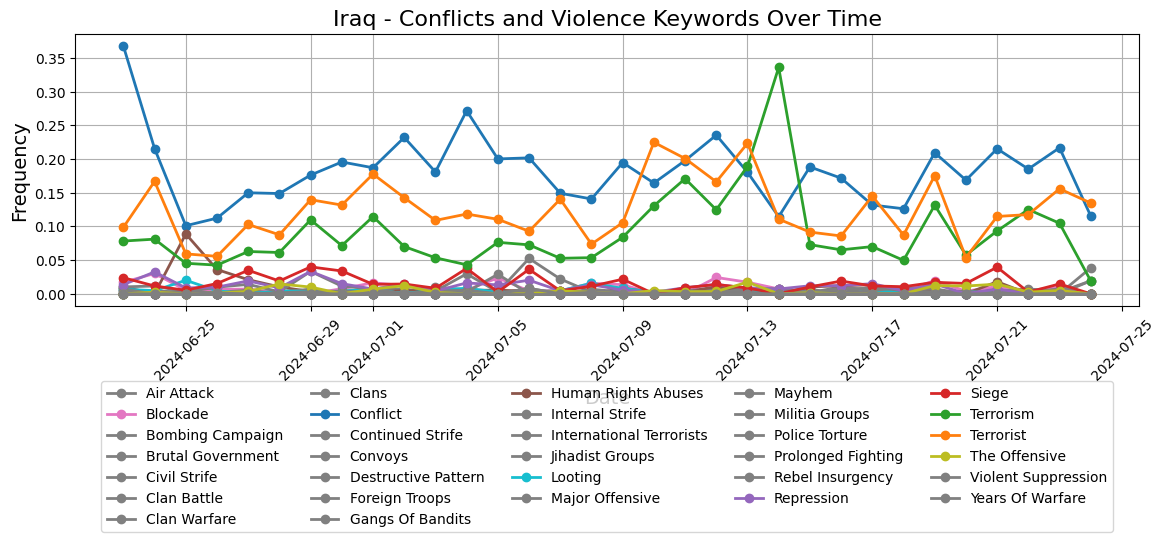

In [39]:
# Plotting
plt.figure(figsize=(12, 6))

# Normalize data and plot
normalized_data = summary_df_loc[category_keywords].apply(lambda x: x / summary_df_loc["count_articles"])

location_name = country_codes[location]

# Calculate the average frequency for each keyword
average_frequencies = normalized_data[category_keywords].mean()

# Create a colormap for the top 10
colors = plt.cm.get_cmap('tab10', 10)  # Adjusting colormap for 10 colors

# Sort keywords by their average frequency and get the top 10
top_10_keywords = average_frequencies.nlargest(10).index.tolist()

# Adding title and labels
plt.title(f'{location_name} - Share of English Articles mentioning Keywords Over Time', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Share of Articles', fontsize=14)

# Loop through each category and plot
for i, keyword in enumerate(category_keywords):
    if keyword in top_10_keywords:
        # Use a different color for the top 10 keywords
        color = colors(top_10_keywords.index(keyword))
    else:
        # Use grey color for the other keywords
        color = 'grey'
    plt.plot(normalized_data[keyword], marker='o', linestyle='-', linewidth=2, color=color)

# Adding title and labels
plt.title(f'{location_name} - {keyword_group_name} Keywords Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Adding a legend only for the top 10 keywords
top_10_keyword_names = [category_keyword_names[category_keywords.index(k)] for k in top_10_keywords]
plt.legend(category_keyword_names, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=5)

# Improve date formatting if the x-axis represents dates
plt.xticks(rotation=45)

# Adding grid lines for better readability
plt.grid(True)

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()